In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
import joblib
import os
import warnings
from sklearn.metrics import mean_absolute_error, mean_squared_error, classification_report

warnings.filterwarnings('ignore')

###  **CARGA DE DATOS Y PREPROCESAMIENTO**

In [2]:
print("Cargando datos...")
train = pd.read_parquet('m5_train.parquet')
val   = pd.read_parquet('m5_val.parquet')

# Definir características
features = ['lag_7', 'lag_21', 'lag_28', 'lag_60',
            'ma_7',  'ma_21',  'ma_28',  'ma_60',
            'std_7', 'std_28',
            'wday', 'month', 'snap', 'sell_price']

# Crear la variable objetivo binaria (hubo venta o no)
train['hubo_venta'] = (train['ventas'] > 0).astype('int8')
val['hubo_venta']   = (val['ventas'] > 0).astype('int8')

# Limpiar nulos generados por los rezagos (lags)
train_clean = train.dropna(subset=features)
val_clean   = val.dropna(subset=features)

# Separar X e y generales
X_train = train_clean[features]
y_train = train_clean['ventas']
y_train_bin = train_clean['hubo_venta']

X_val = val_clean[features]
y_val = val_clean['ventas']
y_val_bin = val_clean['hubo_venta']

# Filtrar conjuntos específicos para la parte de regresión (solo ventas > 0)
mask_pos_train = y_train > 0
X_train_pos = X_train[mask_pos_train]
y_train_pos = y_train[mask_pos_train]

mask_pos_val = y_val > 0
X_val_pos = X_val[mask_pos_val]
y_val_pos = y_val[mask_pos_val]

Cargando datos...


### **FASE DE ENTRENAMIEMTO**

In [3]:
print("\n--- Entrenando XGBoost Classifier ---")
clf = xgb.XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    tree_method='hist',
    random_state=42,
    n_jobs=-1
)

clf.fit(
    X_train, y_train_bin,
    eval_set=[(X_train, y_train_bin), (X_val, y_val_bin)],
    verbose=False
)
results_clf = clf.evals_result()

print("\n--- Entrenando XGBoost Regressor ---")
reg = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=600,             
    learning_rate=0.05,           
    max_depth=8,                  
    subsample=0.8,                
    colsample_bytree=0.8,         
    tree_method='hist',           
    eval_metric='rmse',           
    random_state=42,
    n_jobs=-1
)
# El entrenamiento evalúa únicamente sobre los registros con ventas positivas
reg.fit(
    X_train_pos, y_train_pos,
    eval_set=[(X_train_pos, y_train_pos), (X_val_pos, y_val_pos)],
    verbose=False
)
results_reg = reg.evals_result()


--- Entrenando XGBoost Classifier ---

--- Entrenando XGBoost Regressor ---


### **FASE DE PREDICCIÓN E INTEGRACIÓN HURDLE**

In [4]:
print("\nGenerando predicciones combinadas...")
y_pred_bin = clf.predict(X_val)
y_pred_amt = np.clip(reg.predict(X_val), 0, None)

# Ensamble Hurdle: Multiplicación de ambas fases
y_pred_hurdle = y_pred_bin * y_pred_amt


Generando predicciones combinadas...


### **CÁLCULO DE MÉTRICAS DE EVALUACIÓN**

In [5]:
def calcular_wrmsse_rapido(y_pred, val_clean, train_clean):
    df_val = val_clean[['id', 'ventas']].copy()
    df_val['pred'] = y_pred

    err = df_val.groupby('id').apply(
        lambda x: np.mean((x['ventas'].values - x['pred'].values) ** 2)
    ).reset_index(name='mse')

    escala = train_clean.groupby('id')['ventas'].apply(
        lambda x: np.mean(np.diff(x.values) ** 2)
    ).reset_index(name='escala')

    peso = train_clean.groupby('id')['ventas'].sum().reset_index(name='peso')

    df_m = err.merge(escala, on='id').merge(peso, on='id')
    df_m = df_m[df_m['escala'] > 0]

    return np.sqrt(np.average(df_m['mse'] / df_m['escala'], weights=df_m['peso']))

# Métricas globales del modelo Hurdle
mae  = mean_absolute_error(y_val, y_pred_hurdle)
rmse = np.sqrt(mean_squared_error(y_val, y_pred_hurdle))
wrmsse_score = calcular_wrmsse_rapido(y_pred_hurdle, val_clean, train_clean)


### **VISUALIZACIONES**

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, confusion_matrix, classification_report

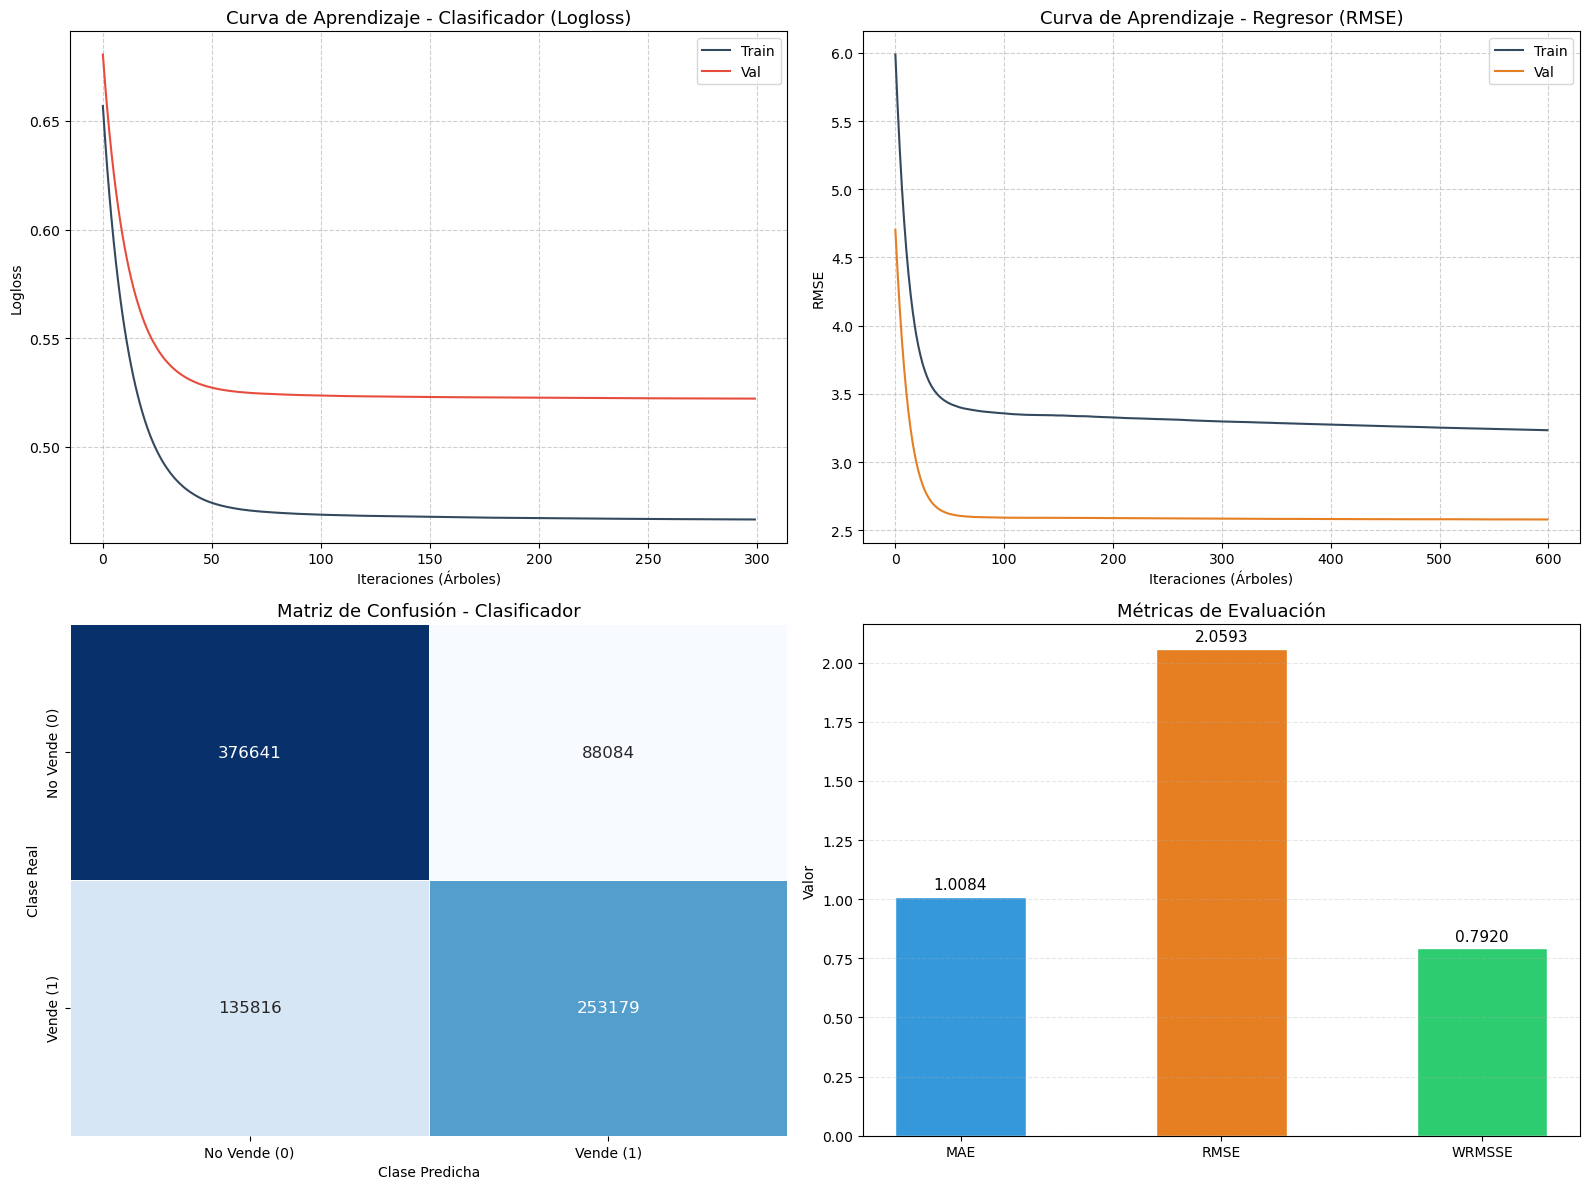

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Curva de Aprendizaje - Clasificador
epochs_clf = len(results_clf['validation_0']['logloss'])
x_axis_clf = range(0, epochs_clf)
axes[0, 0].plot(x_axis_clf, results_clf['validation_0']['logloss'], label='Train', color='#34495e')
axes[0, 0].plot(x_axis_clf, results_clf['validation_1']['logloss'], label='Val', color='#e74c3c')
axes[0, 0].set_title('Curva de Aprendizaje - Clasificador (Logloss)', fontsize=13)
axes[0, 0].set_ylabel('Logloss')
axes[0, 0].set_xlabel('Iteraciones (Árboles)')
axes[0, 0].legend()
axes[0, 0].grid(True, linestyle='--', alpha=0.6)

# Curva de Aprendizaje - Regresor
epochs_reg = len(results_reg['validation_0']['rmse'])
x_axis_reg = range(0, epochs_reg)
axes[0, 1].plot(x_axis_reg, results_reg['validation_0']['rmse'], label='Train', color='#34495e')
axes[0, 1].plot(x_axis_reg, results_reg['validation_1']['rmse'], label='Val', color='#e67e22')
axes[0, 1].set_title('Curva de Aprendizaje - Regresor (RMSE)', fontsize=13)
axes[0, 1].set_ylabel('RMSE')
axes[0, 1].set_xlabel('Iteraciones (Árboles)')
axes[0, 1].legend()
axes[0, 1].grid(True, linestyle='--', alpha=0.6)

# Matriz de Confusión
cm = confusion_matrix(y_val_bin, y_pred_bin)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1, 0], 
            cbar=False, annot_kws={"size": 12}, edgecolor='white', linewidths=0.5)
axes[1, 0].set_title('Matriz de Confusión - Clasificador', fontsize=13)
axes[1, 0].set_ylabel('Clase Real')
axes[1, 0].set_xlabel('Clase Predicha')
axes[1, 0].set_xticklabels(['No Vende (0)', 'Vende (1)'])
axes[1, 0].set_yticklabels(['No Vende (0)', 'Vende (1)'])

# Gráfico de Barras de Métricas Resumen
metricas = ['MAE', 'RMSE', 'WRMSSE']
valores  = [mae, rmse, wrmsse_score]
colores  = ['#3498db', '#e67e22', '#2ecc71']

bars = axes[1, 1].bar(metricas, valores, color=colores, edgecolor='white', width=0.5)

for bar, val in zip(bars, valores):
    axes[1, 1].text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + (max(valores) * 0.01),
                    f'{val:.4f}', ha='center', va='bottom', fontsize=11)

axes[1, 1].set_title('Métricas de Evaluación', fontsize=13)
axes[1, 1].set_ylabel('Valor')
axes[1, 1].grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

### **GUARDAR MODELOS**

In [9]:
os.makedirs('modelos', exist_ok=True)
joblib.dump(clf, 'modelos/clasificador_xgboost_hurdle.pkl')
joblib.dump(reg, 'modelos/regresor_xgboost_hurdle.pkl')
print("\nModelos guardados exitosamente en la carpeta 'modelos/'.")


Modelos guardados exitosamente en la carpeta 'modelos/'.


In [10]:
print("=" * 45)
print("       RESULTADOS DEL MODELO HURDLE (XGBOOST)")
print("=" * 45)
print(f"  MAE                   : {mae:.4f}")
print(f"  RMSE                  : {rmse:.4f}")
print(f"  WRMSSE                : {wrmsse_score:.4f}")
print("=" * 45)

       RESULTADOS DEL MODELO HURDLE (XGBOOST)
  MAE                   : 1.0084
  RMSE                  : 2.0593
  WRMSSE                : 0.7920
